/var/folders/fp/0vqz18r15679y3w674kfj3k40000gq/T/ipykernel_71211/1955542365.py:26: DeprecationWarning: circular_aperture is deprecated. Its new name is make_circular_aperture.
  aperture = circular_aperture(pupil_size)
/var/folders/fp/0vqz18r15679y3w674kfj3k40000gq/T/ipykernel_71211/1955542365.py:29: DeprecationWarning: circular_aperture is deprecated. Its new name is make_circular_aperture.
  small_aperture = circular_aperture(small_pupil_size)


Telescope Pupil Shape: (256, 256)
Masking Pupil Shape: (256, 256)
Scale 2: P2V error: 6.9273575023421285 rad, 1.1025231890624758 waves, defocus distance: 13994.908389652417 microns
Scale 1: P2V error: 3.4636787511710643 rad, 0.5512615945312379 waves, defocus distance: 6997.454194826209 microns
Median error of 0.018920708761055265 radians.
Median error in nanometers: 1.9573608119806496 nm
RMS error: 0.3306960756853361 radians


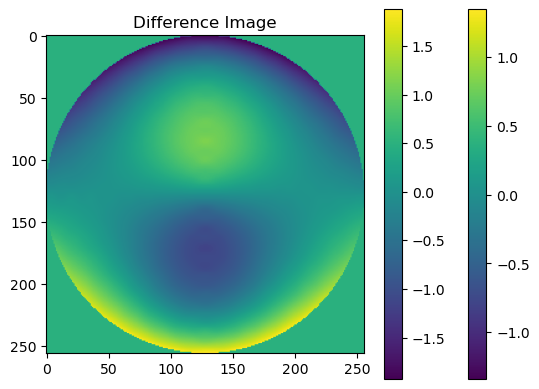

In [3]:
from hcipy import *
import numpy as np
import matplotlib.pyplot as plt
from image_sharpening import FocusDiversePhaseRetrieval, ft_rev, mft_rev, InstrumentConfiguration
from skimage.transform import resize

#Constants
pupil_size = 10.12e-3
small_pupil_size = 9.5e-3 
focal_length = 500e-3
wavelength = 650e-9
grid_size = 256
q = 16
num_airy = 16
f = focal_length
D = pupil_size
dx_list = [2.0071, 2.0071]

# Create the pupil grid
pupil_grid = make_pupil_grid(grid_size, pupil_size)

# Create the focal grid
focal_grid = make_focal_grid(q=q, num_airy=num_airy, pupil_diameter=pupil_size, focal_length=focal_length, reference_wavelength=wavelength)

# Aperture setup
aperture = circular_aperture(pupil_size)
telescope_pupil = aperture(pupil_grid).reshape(grid_size, grid_size)  # Reshape to (256, 256)

small_aperture = circular_aperture(small_pupil_size)
masking_pupil = small_aperture(pupil_grid).reshape(grid_size, grid_size)  # Reshape to (256, 256)

# Debugging: Print shapes
print(f"Telescope Pupil Shape: {telescope_pupil.shape}")
print(f"Masking Pupil Shape: {masking_pupil.shape}")

def phase_to_m(phase, wv):
    return phase * wv / (2 * np.pi)

def p_to_delta(P, f, D):
    return 8 * P * (f/D)**2

def delta_to_p(delta, f, D):
    return -1 * delta / (8 * (f/D)**2)

def propagate_image(defocus_phase, test_ab, telescope_pupil, wavelength):
    prop_p2f = FraunhoferPropagator(pupil_grid, focal_grid, focal_length=focal_length)
    combined_phase = (test_ab + defocus_phase).reshape(grid_size, grid_size)  # Reshape phase to (256, 256)
    pupil_field = telescope_pupil * np.exp(complex(0, 1) * combined_phase)  # Both arrays are now (256, 256)
    wavefront = Wavefront(pupil_field, wavelength)
    focal_field = prop_p2f.forward(wavefront)
    focal_intensity = np.abs(focal_field.electric_field.reshape(focal_grid.shape))**2
    return focal_intensity
def calculate_defocus_params(example_defocus, scale, f, D):
    """
    Calculates P2V error and defocus distance for given defocus phase and scale.

    Parameters
    ----------
    example_defocus : np.ndarray
        Array representing the defocus phase.
    scale : float
        Scale factor for the defocus phase.
    f : float
        Focal length of the system.
    D : float
        Size of the pupil.

    Returns
    -------
    tuple
        P2V error in radians and defocus distance.
    """

    defocus_phase = example_defocus * scale
    p2v_radians = np.max(defocus_phase) - np.min(defocus_phase)
    p2v_m = phase_to_m(p2v_radians, 650e-9)
    delta = p_to_delta(p2v_m, f, D)
    delta=delta if scale>0 else -1*delta
    return p2v_radians, delta

def generate_defocus_lists(example_defocus, scales, f, D, test_ab, telescope_pupil, wavelength):
    """
    Generates defocus lists and calculates PSF for each scale.

    Parameters
    ----------
    example_defocus : np.ndarray
        Array representing the example defocus.
    scales : list of float
        List of scales to apply to the defocus phase.
    f : float
        Focal length of the system.
    D : float
        Size of the pupil.
    test_ab : np.ndarray
        Array representing the test aberration.
    telescope_pupil : np.ndarray
        Array representing the telescope pupil.
    wavelength : float
        Wavelength of light in meters.

    Returns
    -------
    tuple
        List of PSFs and list of defocus distances.
    """
    psf_list = []
    distance_list = []

    # Ensure the shapes are compatible
    example_defocus = example_defocus.reshape(telescope_pupil.shape)
    test_ab = test_ab.reshape(telescope_pupil.shape)

    # Calculate no-defocus image
    no_defocus_phase = np.zeros_like(example_defocus)
    no_defocus_image = propagate_image(no_defocus_phase, test_ab, telescope_pupil, wavelength)
    psf_list.append(no_defocus_image)

    for scale in scales:
        # Calculate P2V error and defocus distance
        p2v_radians, delta = calculate_defocus_params(example_defocus, scale, f, D)
        print(f'Scale {scale}: P2V error: {p2v_radians} rad, {p2v_radians/(2*np.pi)} waves, defocus distance: {delta*1e6} microns')
        defocus_image = propagate_image(example_defocus * scale, test_ab, telescope_pupil, wavelength)
        psf_list.append(defocus_image)
        distance_list.append(delta * 1e6)  # Defocus distance in microns

    return psf_list, distance_list, dx_list

def run_focus_diverse_phase_retrieval_v2(scales=[2, 1], test_ab_scale=0.75):
    pupil_grid = make_pupil_grid(grid_size, pupil_size)
    aperture = make_circular_aperture(pupil_size)
    telescope_pupil = aperture(pupil_grid).reshape(grid_size, grid_size)  # Reshape to (256, 256)
    small_aperture = make_circular_aperture(small_pupil_size)
    masking_pupil = small_aperture(pupil_grid).reshape(grid_size, grid_size)  # Reshape to (256, 256)

    wavefront = Wavefront(telescope_pupil, wavelength=wavelength)
    focal_grid = make_focal_grid(q=q, num_airy=num_airy, pupil_diameter=pupil_size, focal_length=focal_length, reference_wavelength=wavelength)
    
    prop_p2f = FraunhoferPropagator(pupil_grid, focal_grid, focal_length=focal_length)
    pupil_image = wavefront.copy()

    influence_functions = make_zernike_basis(256, pupil_size, pupil_grid)
    test_ab = test_ab_scale * influence_functions[6].reshape(grid_size, grid_size)  # Ensure 2D shape (256, 256)
    example_defocus = influence_functions[3].reshape(grid_size, grid_size)  # Ensure 2D shape (256, 256)

    psf_list, distance_list, dx_list = generate_defocus_lists(example_defocus, scales, f, D, test_ab, telescope_pupil, wavelength)

    mp = FocusDiversePhaseRetrieval(psf_list, wavelength, dx_list, distance_list)
    for i in range(200):
        psf00 = mp.step()

    seal_params = {'image_dx': 2.0071, 'efl': focal_length * 1e3, 'wavelength': 0.65, 'pupil_size': pupil_size * 1e3}
    conf = InstrumentConfiguration(seal_params)
    raw_pupil_phase = np.angle(mft_rev(psf00, conf))
    
    pupil_phase = resize(raw_pupil_phase, (256, 256)) * telescope_pupil

    pupil_image.electric_field = np.exp(complex(0, 1)*telescope_pupil*(test_ab))
    med_subtracted = pupil_phase - np.median(pupil_phase[masking_pupil > 0])
    pupil_image_phase = pupil_image.phase.reshape(pupil_phase.shape)

    difference_image = pupil_image_phase - med_subtracted
    plt.imshow(difference_image * masking_pupil)
    plt.colorbar()

    check_error_region = (pupil_image_phase - med_subtracted)[masking_pupil > 0]
    print(f'Median error of {np.median(check_error_region)} radians.')
    nm_med = phase_to_m(np.median(check_error_region), wavelength) * 1e9
    print(f'Median error in nanometers: {nm_med} nm')

    valid_phase_values = med_subtracted[telescope_pupil > 0]
    mean_phase = np.mean(valid_phase_values)
    rms_error = np.sqrt(np.mean((valid_phase_values - mean_phase) ** 2))
    print(f"RMS error: {rms_error} radians")

    return {"pupil_phase": pupil_phase, "difference_image": difference_image, "psf_list": psf_list, "p2v_error": np.max(pupil_phase) - np.min(pupil_phase), "rms_error": rms_error, "nm_med": nm_med}

# Call the function
scales = [2, 1]
test_ab_scale = 0.5
results = run_focus_diverse_phase_retrieval_v2(scales, test_ab_scale)
defocus_images(psf_list)


# Visualize difference image
plt.imshow(results["difference_image"])
plt.colorbar()
plt.title("Difference Image")
plt.show()
